In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsforecast.utils import AirPassengersDF
import os

/usr/local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data =AirPassengersDF
series = data['y']

In [4]:
data

,unique_id,ds,y
0,1.0,1949-01-31,112.0
1,1.0,1949-02-28,118.0
2,1.0,1949-03-31,132.0
3,1.0,1949-04-30,129.0
4,1.0,1949-05-31,121.0
...,...,...,...
139,1.0,1960-08-31,606.0
140,1.0,1960-09-30,508.0
141,1.0,1960-10-31,461.0
142,1.0,1960-11-30,390.0


/tmp/ipykernel_12088/4203319542.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  data.index.freq = 'M'


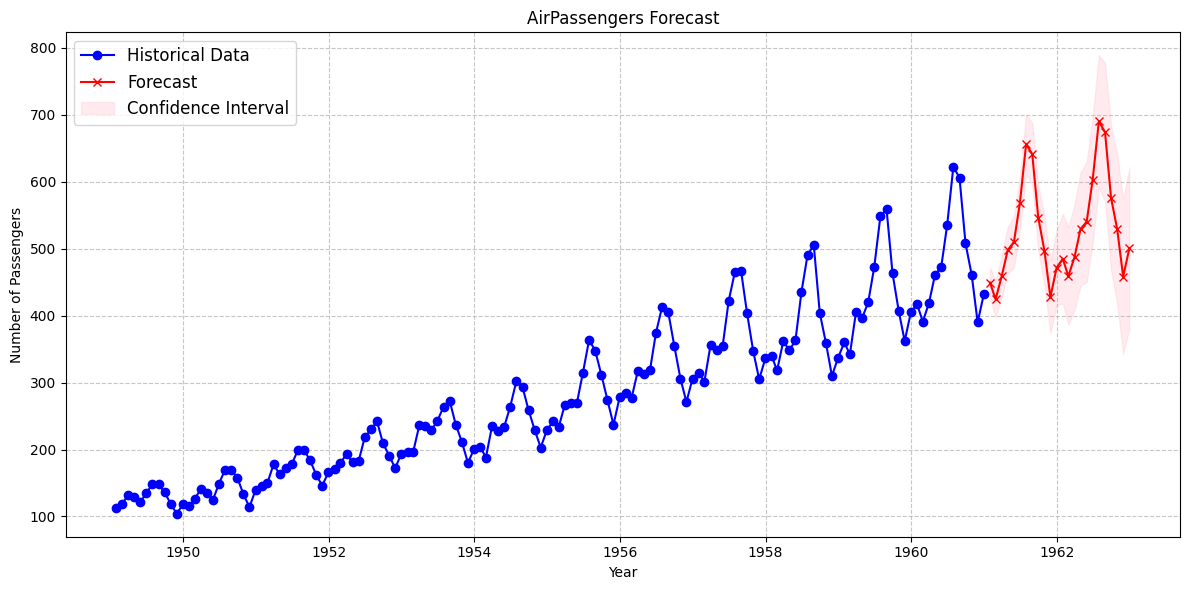

In [6]:
# Ensure the datetime index is set with a frequency
data = data.set_index('ds')
data.index.freq = 'M'

# Fit a SARIMA model to the historical series (using typical parameters for AirPassengers)
model = sm.tsa.statespace.SARIMAX(data['y'], order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit(disp=False)

# Forecast the next 24 months
forecast_steps = 24
forecast_object = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_object.predicted_mean
forecast_conf_int = forecast_object.conf_int()

# Plot the historical data along with the forecast and its confidence interval
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['y'], label='Historical Data', color='blue', marker='o')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red', marker='x')
plt.fill_between(forecast_conf_int.index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.3, label='Confidence Interval')
plt.title("AirPassengers Forecast")
plt.xlabel("Year")
plt.ylabel("Number of Passengers")
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(os.path.join(FIGURE_SAVE_PATH, "airpassengers_forecast.png"))
plt.show()

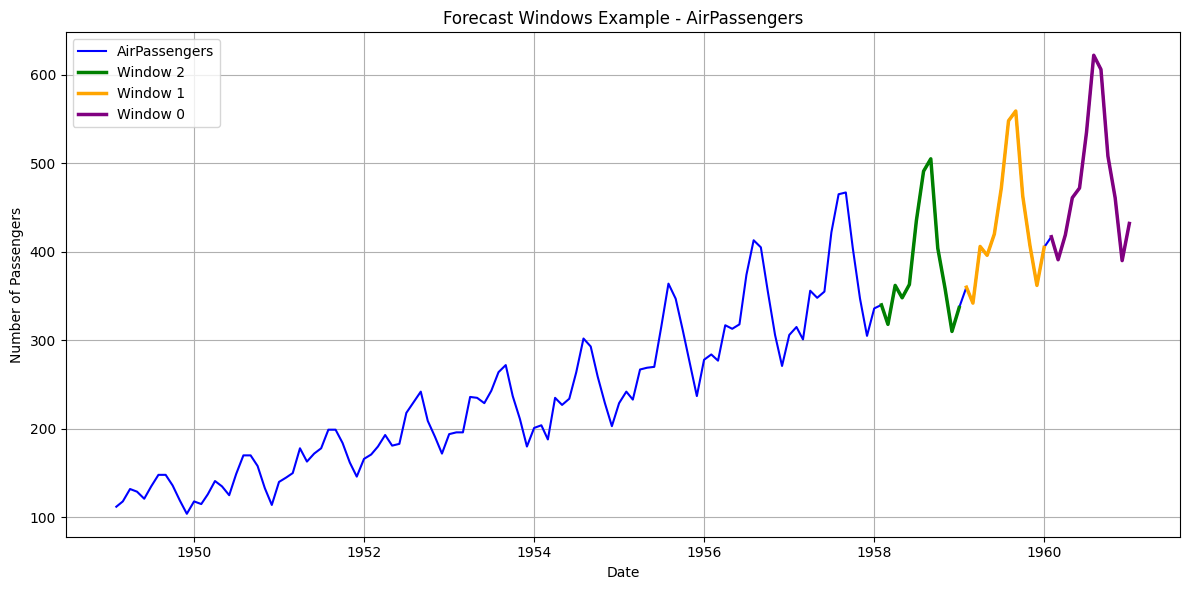

In [ ]:

plt.figure(figsize=(12, 6))
# Plot the full series in blue
plt.plot(data.index, data['y'], color='blue', label='AirPassengers')
colors = ['green', 'orange', 'purple']
# Highlight the last 3 windows of 12 points (last 36 datapoints) in red
start_index = len(data) - 36
for i in range(3):
    window = data.iloc[start_index + i*12 : start_index + (i+1)*12]
    plt.plot(window.index, window['y'], color=colors[i], linewidth=2.5, 
             label=f'Window {2-i}')

plt.title("Forecast Windows Example - AirPassengers")
plt.xlabel("Date")
plt.ylabel("Number of Passengers")
# add legend with description of each color
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
def plot_decomposition(decomposition_result, title, filename=None):
    """Plots all components of a time series decomposition with aligned x-axes."""
    # Create a figure with subplots
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    
    # Get the date range
    observed_index = decomposition_multiplicative.observed.index
    x_min = observed_index.min()
    x_max = observed_index.max()
    
    # Plot each component
    axes[0].plot(observed_index, decomposition_multiplicative.observed, label='Observed', color='blue')
    axes[0].set_title('Observed')
    axes[0].set_ylabel('Value')
    # axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    axes[1].plot(observed_index, decomposition_multiplicative.trend, label='Trend', color='orange')
    axes[1].set_title('Trend')
    axes[1].set_ylabel('Value')
    # axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)
    
    axes[2].plot(observed_index, decomposition_multiplicative.seasonal, label='Seasonal', color='green')
    axes[2].set_title('Seasonal')
    axes[2].set_ylabel('Factor')
    # axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)
    
    axes[3].plot(observed_index, decomposition_multiplicative.resid, label='Residual', color='red')
    axes[3].set_title('Residual')
    axes[3].set_ylabel('Factor')
    axes[3].set_xlabel('Year')
    # axes[3].legend()
    axes[3].grid(True, linestyle='--', alpha=0.7)
    
    # Format x-axis for all subplots
    for ax in axes:
        ax.xaxis.set_major_locator(YearLocator(base=2))
        ax.xaxis.set_major_formatter(DateFormatter('%Y'))
        ax.set_xlim(x_min, x_max)  # Ensure all plots have the same x-axis range
    
    fig.suptitle(title, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.97])  # Add space for suptitle
    
    plt.show()


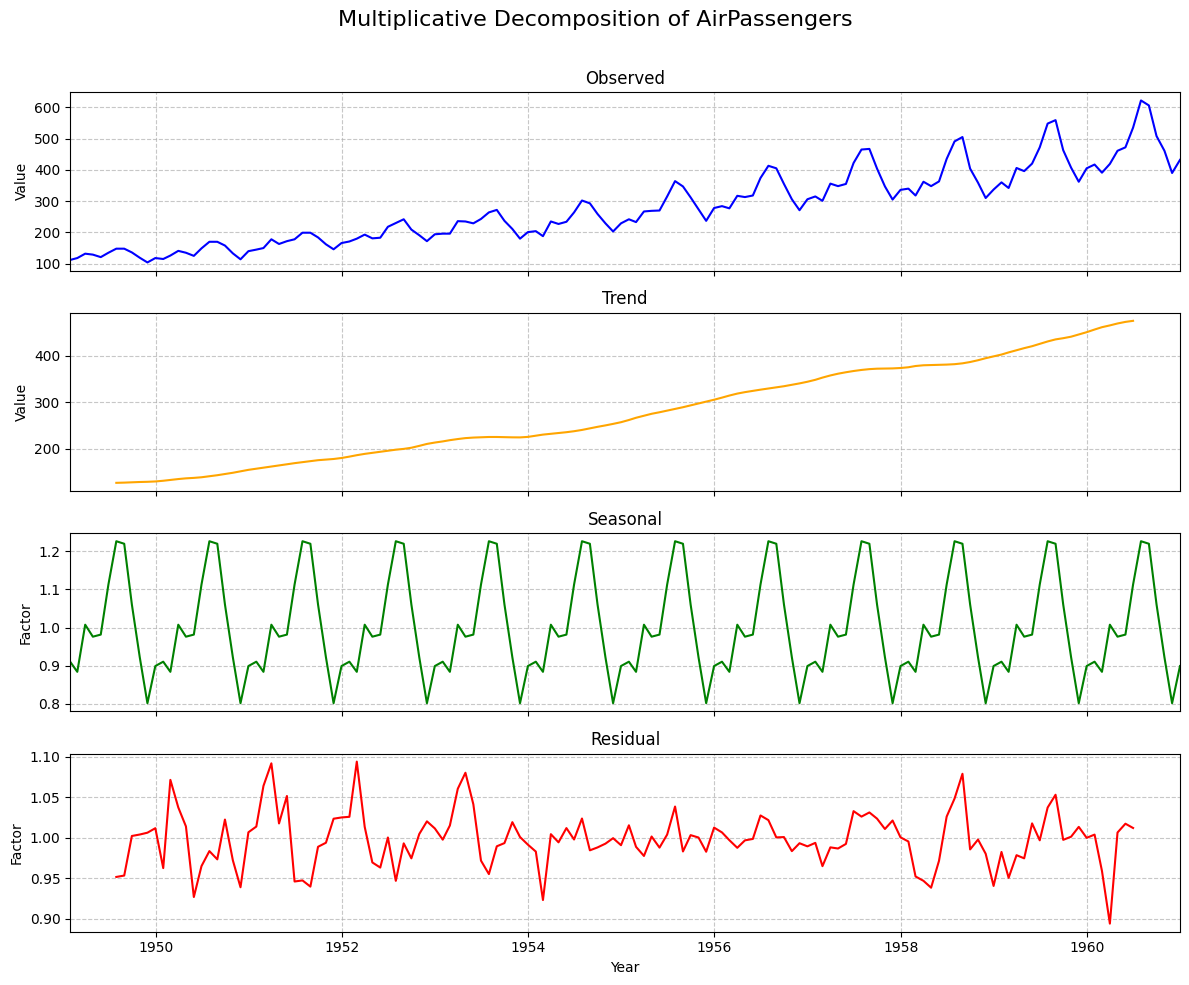

In [19]:
plot_decomposition(decomposition_multiplicative, "Multiplicative Decomposition of AirPassengers", "airpassengers_decomposition_multiplicative.png")

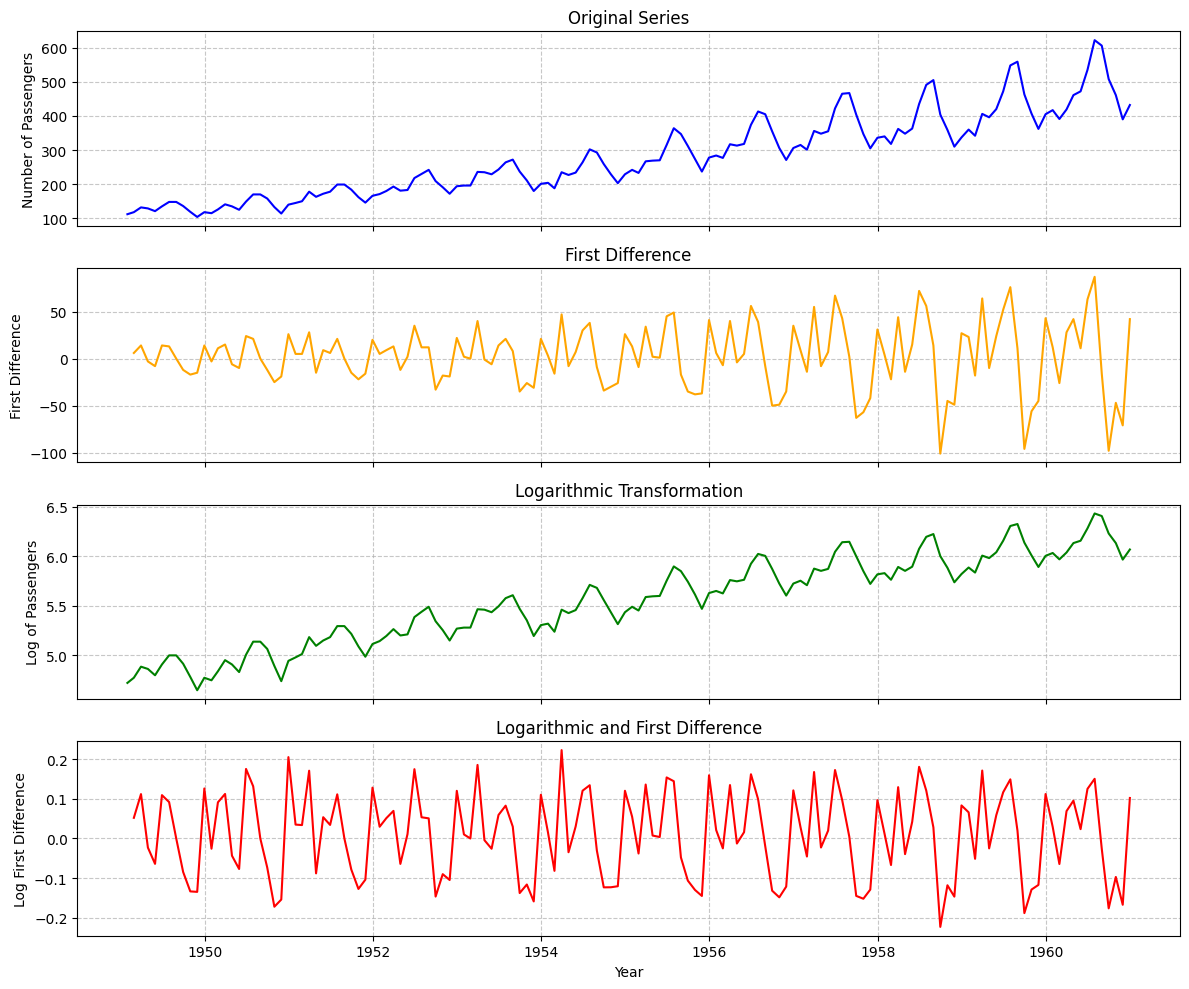

In [ ]:
first_diff = data.diff().dropna()
# logarithmic stabilization

data['log_y'] = np.log(data['y'])

# combined log and first difference
data['log_diff_y'] = data['log_y'].diff().dropna()




fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
axes[0].plot(data.index, data['y'], linestyle='-', color='blue')
axes[0].set_title('Original Series')
axes[0].set_ylabel('Number of Passengers')
axes[1].plot(first_diff.index, first_diff['y'], linestyle='-', color='orange')
axes[1].set_title('First Difference')
axes[1].set_ylabel('First Difference')
axes[2].plot(data.index, data['log_y'], linestyle='-', color='green')
axes[2].set_title('Logarithmic Transformation')
axes[2].set_ylabel('Log of Passengers')
axes[3].plot(data.index, data['log_diff_y'], linestyle='-', color='red')
axes[3].set_title('Logarithmic and First Difference')
axes[3].set_ylabel('Log First Difference')
axes[3].set_xlabel('Year')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[2].grid(True, linestyle='--', alpha=0.7)
axes[3].grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



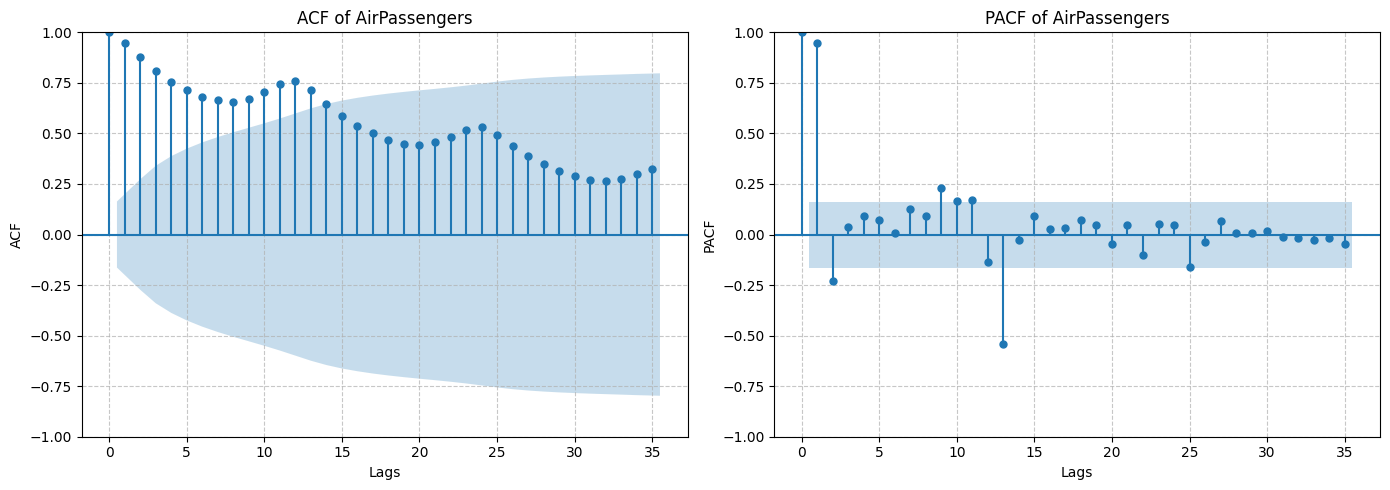

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
plot_acf(data['y'].dropna(), ax=axes[0], lags=35, title='ACF of AirPassengers')
plot_pacf(data['y'].dropna(), ax=axes[1], lags=35, title='PACF of AirPassengers')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('ACF')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('PACF')

plt.tight_layout()
plt.show()